In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "ground_state"
ESP_DIR = RESULTS / "esp"
ESP_FIGURES = ROOT / "figures" / "esp"
ESP_FIGURES.mkdir(parents=True, exist_ok=True)

esp_metrics = pd.read_csv(ESP_DIR / "esp_surface_metrics.csv")
esp_extrema = pd.read_csv(ESP_DIR / "esp_extrema_from_text.csv")
esp_extrema_pdb = pd.read_csv(ESP_DIR / "esp_extrema_from_pdb.csv")

esp_extrema["esp_value_ev"] = esp_extrema["esp_value"] * 27.211386245988
esp_extrema.head()

,system,source_file,line,extremum_type,x,y,z,esp_value,raw_line,esp_value_ev
0,pdi,calculations/pdi/multiwfn_analysis/esp/pdi_esp...,3,minimum,-6.986352,3.443465,-0.002166,-0.049021,1 -0.04902076 -1.333923 -30.761020 -6....,-1.333923
1,pdi,calculations/pdi/multiwfn_analysis/esp/pdi_esp...,4,minimum,-6.983137,-3.442856,-0.005394,-0.049020,2 -0.04902005 -1.333903 -30.760571 -6....,-1.333904
2,pdi,calculations/pdi/multiwfn_analysis/esp/pdi_esp...,5,minimum,-5.945539,-0.012236,-1.892238,0.010563,3 0.01056332 0.287443 6.628591 -5....,0.287443
3,pdi,calculations/pdi/multiwfn_analysis/esp/pdi_esp...,6,minimum,-6.053296,-0.002687,1.859161,0.010553,4 0.01055305 0.287163 6.622147 -6....,0.287163
4,pdi,calculations/pdi/multiwfn_analysis/esp/pdi_esp...,7,minimum,-3.295829,-2.126946,1.953611,0.007430,5 0.00742971 0.202173 4.662217 -3....,0.202173


## ESP extrema analysis plots

In [2]:
%matplotlib inline
plt.style.use("default")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
    }
)


SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Functionalized PDI",
}

SYSTEM_COLORS = {
    "pdi": "#0018F9",
    "pdi_terminal_functionalized": "#F28500",
}

EXTREMUM_COLORS = {
    "minimum": "#0018F9",
    "maximum": "#F28500",
}

DEFAULT_COLORS = ["#0018F9", "#F28500", "#6B7CDB", "#D08A3A", "#9AA0A6"]

FIGURE_BACKGROUND = "white"
AXIS_COLOR = "black"
GRID_COLOR = "#9AA0A6"

def system_label(system):
    return SYSTEM_LABELS.get(system, system.replace("_", " ").title())

def system_color(system, index=0):
    return SYSTEM_COLORS.get(system, DEFAULT_COLORS[index % len(DEFAULT_COLORS)])

def practical_chemistry_axis(ax, xlabel=None, ylabel=None, title=None, legend=False, legend_loc="best"):
    fig = ax.figure
    fig.patch.set_facecolor(FIGURE_BACKGROUND)
    ax.set_facecolor(FIGURE_BACKGROUND)

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
        spine.set_color(AXIS_COLOR)

    ax.tick_params(axis="both", labelsize=14, direction="in", width=1.4, colors=AXIS_COLOR)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color(AXIS_COLOR)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=22, fontweight="bold", color=AXIS_COLOR)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=22, fontweight="bold", color=AXIS_COLOR)
    if title:
        ax.set_title(title, fontsize=18, fontweight="bold", color=AXIS_COLOR)

    #ax.grid(True, which="major", ls="--", lw=0.5, alpha=0.35, color=GRID_COLOR)

    if legend:
        legend_obj = ax.legend(loc=legend_loc, prop={"size": 10, "weight": "bold"})
        legend_obj.get_frame().set_facecolor(FIGURE_BACKGROUND)
        legend_obj.get_frame().set_edgecolor(AXIS_COLOR)
        for text in legend_obj.get_texts():
            text.set_color(AXIS_COLOR)

    return ax

def annotate_bars(ax, bars, fmt="{:+.4f}"):
    for bar in bars:
        value = bar.get_height()
        if value >= 0:
            va = "bottom"
            offset = 0.002
        else:
            va = "top"
            offset = -0.002
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            fmt.format(value),
            ha="center",
            va=va,
            fontsize=12,
            fontweight="bold",
        )

def save_figure(fig, stem):
    fig.savefig(ESP_FIGURES / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(ESP_FIGURES / f"{stem}.png", bbox_inches="tight", dpi=300)

global_rows = []
for system, group in esp_extrema.groupby("system"):
    minima = group[group["extremum_type"] == "minimum"]
    maxima = group[group["extremum_type"] == "maximum"]
    if not minima.empty:
        row = minima.loc[minima["esp_value"].idxmin()]
        global_rows.append({"system": system, "extremum_type": "minimum", "esp_value": row["esp_value"], "x": row["x"], "y": row["y"], "z": row["z"]})
    if not maxima.empty:
        row = maxima.loc[maxima["esp_value"].idxmax()]
        global_rows.append({"system": system, "extremum_type": "maximum", "esp_value": row["esp_value"], "x": row["x"], "y": row["y"], "z": row["z"]})

global_extrema = pd.DataFrame(global_rows)
global_extrema["esp_value_ev"] = global_extrema["esp_value"] * 27.211386245988
global_extrema

,system,extremum_type,esp_value,x,y,z,esp_value_ev
0,pdi,minimum,-0.049032,6.983132,-3.443218,-0.034141,-1.334234
1,pdi,maximum,0.062438,-7.884733,0.015418,0.009944,1.699035
2,pdi_terminal_functionalized,minimum,-0.048156,-6.531101,3.751433,-0.054162,-1.310388
3,pdi_terminal_functionalized,maximum,0.053257,-0.032349,4.501467,-0.140451,1.449188


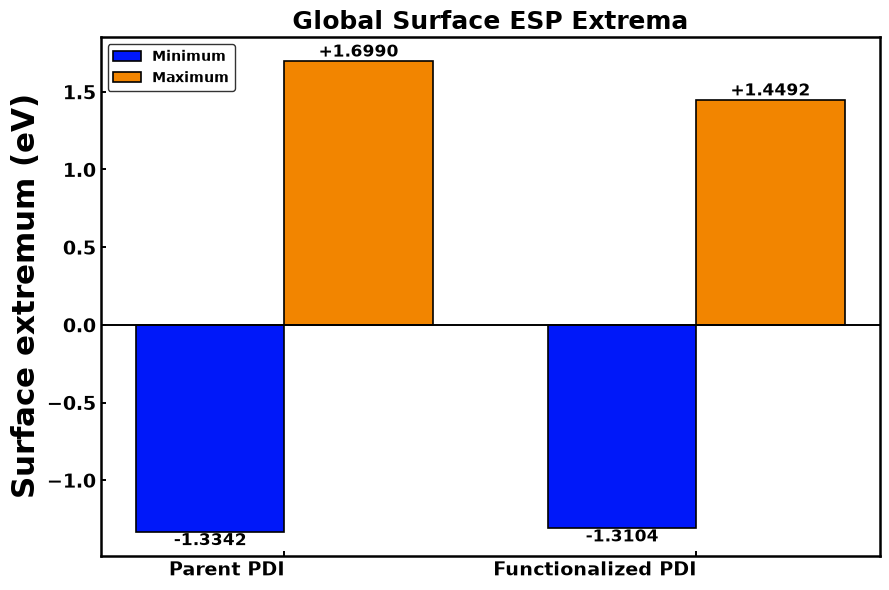

In [3]:
# Global minimum and maximum comparison
plot_df = global_extrema.pivot(index="system", columns="extremum_type", values="esp_value_ev").loc[
    [system for system in ["pdi", "pdi_terminal_functionalized"] if system in set(global_extrema["system"])]
]

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(plot_df))
width = 0.36

min_bars = ax.bar(
    x - width / 2,
    plot_df["minimum"],
    width=width,
    color=EXTREMUM_COLORS["minimum"],
    edgecolor="black",
    linewidth=1.2,
    label="Minimum",
)
max_bars = ax.bar(
    x + width / 2,
    plot_df["maximum"],
    width=width,
    color=EXTREMUM_COLORS["maximum"],
    edgecolor="black",
    linewidth=1.2,
    label="Maximum",
)

ax.axhline(0, color="black", lw=1.4)
ax.set_xticks(x)
ax.set_xticklabels([system_label(system) for system in plot_df.index], rotation=0, ha="right")
annotate_bars(ax, min_bars)
annotate_bars(ax, max_bars)
practical_chemistry_axis(
    ax,
    ylabel="Surface extremum (eV)",
    title="Global Surface ESP Extrema",
    legend=True,
    legend_loc="upper left",
)
plt.tight_layout()
save_figure(fig, "global_surface_esp_extrema")
plt.show()

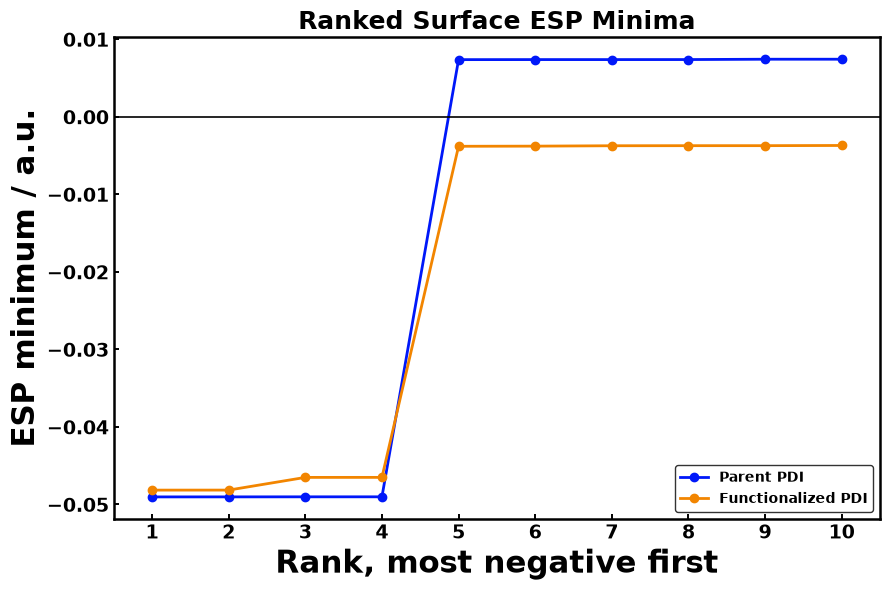

In [4]:
# Ranked minima
fig, ax = plt.subplots(figsize=(9, 6))

for i, (system, group) in enumerate(esp_extrema[esp_extrema["extremum_type"] == "minimum"].groupby("system")):
    ranked = (
        group
        .sort_values("esp_value", ascending=True)
        .head(10)
        .reset_index(drop=True)
    )
    ranked["rank"] = ranked.index + 1
    ax.plot(
        ranked["rank"],
        ranked["esp_value"],
        "o-",
        lw=2,
        ms=6,
        color=system_color(system, i),
        label=system_label(system),
    )

ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)
practical_chemistry_axis(
    ax,
    xlabel="Rank, most negative first",
    ylabel="ESP minimum / a.u.",
    title="Ranked Surface ESP Minima",
    legend=True,
    legend_loc="lower right",
)
plt.tight_layout()
save_figure(fig, "ranked_surface_esp_minima")
plt.show()

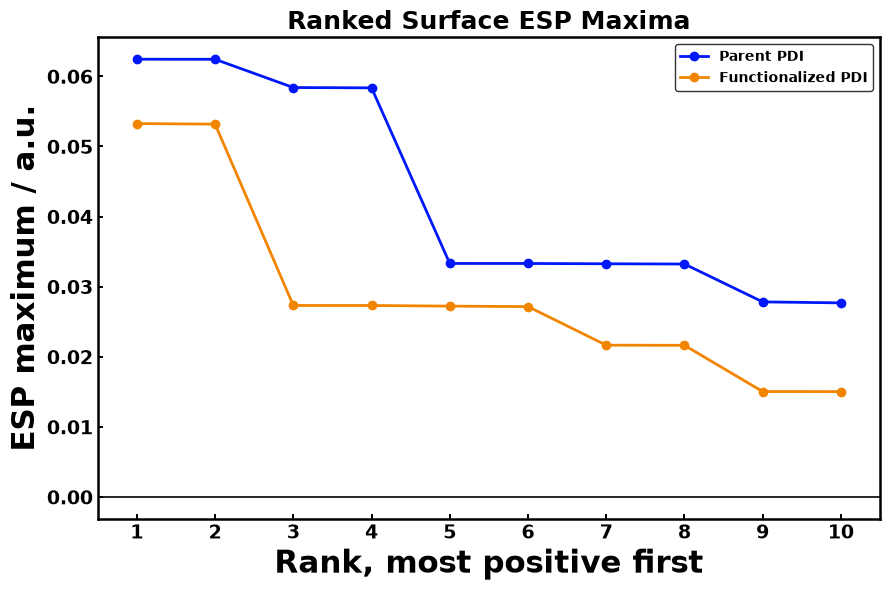

In [5]:
# Ranked maxima
fig, ax = plt.subplots(figsize=(9, 6))

for i, (system, group) in enumerate(esp_extrema[esp_extrema["extremum_type"] == "maximum"].groupby("system")):
    ranked = (
        group
        .sort_values("esp_value", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    ranked["rank"] = ranked.index + 1
    ax.plot(
        ranked["rank"],
        ranked["esp_value"],
        "o-",
        lw=2,
        ms=6,
        color=system_color(system, i),
        label=system_label(system),
    )

ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)
practical_chemistry_axis(
    ax,
    xlabel="Rank, most positive first",
    ylabel="ESP maximum / a.u.",
    title="Ranked Surface ESP Maxima",
    legend=True,
    legend_loc="upper right",
)
plt.tight_layout()
save_figure(fig, "ranked_surface_esp_maxima")
plt.show()

In [6]:
# Export ESP summary tables
summary_rows = []
for system, group in esp_extrema.groupby("system"):
    minima = group[group["extremum_type"] == "minimum"]
    maxima = group[group["extremum_type"] == "maximum"]
    global_minimum = minima["esp_value"].min() if not minima.empty else np.nan
    global_maximum = maxima["esp_value"].max() if not maxima.empty else np.nan
    summary_rows.append(
        {
            "system": system,
            "global_minimum": global_minimum,
            "global_maximum": global_maximum,
            "esp_range": global_maximum - global_minimum,
            "number_of_minima": len(minima),
            "number_of_maxima": len(maxima),
        }
    )

esp_summary = pd.DataFrame(summary_rows)
system_order = [system for system in ["pdi", "pdi_terminal_functionalized"] if system in set(esp_summary["system"])]
esp_summary["system"] = pd.Categorical(esp_summary["system"], categories=system_order, ordered=True)
esp_summary = esp_summary.sort_values("system").reset_index(drop=True)
esp_summary["system"] = esp_summary["system"].astype(str)

top_10_esp_minima = (
    esp_extrema[esp_extrema["extremum_type"] == "minimum"]
    .sort_values(["system", "esp_value"], ascending=[True, True])
    .groupby("system", group_keys=False)
    .head(10)
    .copy()
)
top_10_esp_minima["rank"] = top_10_esp_minima.groupby("system").cumcount() + 1

top_10_esp_maxima = (
    esp_extrema[esp_extrema["extremum_type"] == "maximum"]
    .sort_values(["system", "esp_value"], ascending=[True, False])
    .groupby("system", group_keys=False)
    .head(10)
    .copy()
)
top_10_esp_maxima["rank"] = top_10_esp_maxima.groupby("system").cumcount() + 1

esp_summary.to_csv(ESP_DIR / "esp_summary.csv", index=False)
top_10_esp_minima.to_csv(ESP_DIR / "top_10_esp_minima.csv", index=False)
top_10_esp_maxima.to_csv(ESP_DIR / "top_10_esp_maxima.csv", index=False)

esp_summary


,system,global_minimum,global_maximum,esp_range,number_of_minima,number_of_maxima
0,pdi,-0.049032,0.062438,0.111471,20,18
1,pdi_terminal_functionalized,-0.048156,0.053257,0.101413,27,32


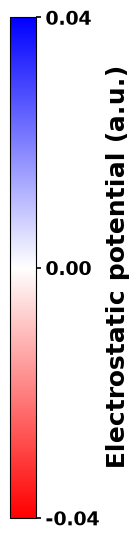

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl

OUTPUT = Path("../figures/esp")
OUTPUT.mkdir(parents=True, exist_ok=True)

vmin = -0.04
vmax = 0.04

# Reverse this colormap if your VMD convention is opposite.
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "esp_rwb",
    [
        (0.0, "red"),
        (0.5, "white"),
        (1.0, "blue"),
    ],
)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(1.5, 5.5))

colorbar = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap,
    norm=norm,
    orientation="vertical",
)

colorbar.set_label(
    "Electrostatic potential (a.u.)",
    fontsize=18,
    fontweight="bold",
)

colorbar.set_ticks([vmin, 0.0, vmax])
colorbar.set_ticklabels(
    [
        f"{vmin:.2f}",
        "0.00",
        f"{vmax:.2f}",
    ]
)

colorbar.ax.tick_params(
    labelsize=14,
    width=1.2,
    #direction="in",
)

for label in colorbar.ax.get_yticklabels():
    label.set_fontweight("bold")

fig.tight_layout()

fig.savefig(
    OUTPUT / "esp_colorbar.pdf",
    bbox_inches="tight",
)

plt.show()